In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv("../../data/fifa_world_cup_2026_player_performance.csv")
print("Dataset loaded successfully")
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])
df.head()

Dataset loaded successfully
Rows: 54600
Columns: 75


,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,club_name,market_value_eur,match_id,match_date,stadium,city,opponent_team,tournament_stage,match_result,goals_team,goals_opponent,minutes_played,goals,assists,shots,shots_on_target,expected_goals_xg,expected_assists_xa,key_passes,successful_passes,total_passes,pass_accuracy,dribbles_attempted,successful_dribbles,crosses,successful_crosses,tackles,interceptions,clearances,blocks,aerial_duels_won,aerial_duels_lost,recoveries,defensive_actions,fouls_committed,fouls_suffered,yellow_cards,red_cards,offsides,saves,save_percentage,punches,clean_sheet,goals_conceded,penalty_saves,distance_covered_km,sprint_distance_km,top_speed_kmh,accelerations,decelerations,stamina_score,player_rating,performance_score,offensive_contribution,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,RB Salzburg,4384884,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,72,0,0,0,0,0.00,0.00,0,15,26,0.59,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,4,0.83,0,1,0,0,7.8,0.7,26.5,13,23,81.9,5.6,50.9,3.3,48.2,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,Chelsea,4918927,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,90,0,0,0,0,0.01,0.00,1,35,40,0.89,1,0,1,0,0,1,3,1,2,0,2,5,0,1,0,0,0,0,0.00,0,0,0,0,10.4,1.1,29.0,19,17,85.5,5.7,55.9,37.9,29.4,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,AIK,125015698,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,73,1,0,2,0,0.08,0.07,2,72,85,0.85,0,0,3,0,1,1,0,0,1,2,4,2,0,0,0,0,0,0,0.00,0,0,0,0,8.8,1.3,33.7,30,19,88.8,8.3,82.9,79.8,78.6,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,PSV Eindhoven,11805512,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,80,1,1,5,2,0.00,0.21,0,12,19,0.67,1,0,0,0,1,1,1,0,3,0,1,3,0,1,0,0,0,0,0.00,0,0,0,0,9.6,1.0,32.1,26,19,89.2,6.9,67.5,47.3,6.9,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,Juventus,13325174,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,79,0,0,1,0,0.00,0.00,1,33,44,0.76,2,1,0,0,1,3,0,2,1,2,4,6,0,0,0,0,0,0,0.00,0,0,0,0,7.5,0.7,30.5,23,18,73.6,5.7,55.4,33.0,75.6,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


In [2]:
print("Columns:"); print(df.columns.tolist()); print("\nData types:"); print(df.dtypes)

Columns:
['player_id', 'player_name', 'age', 'nationality', 'team', 'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot', 'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium', 'city', 'opponent_team', 'tournament_stage', 'match_result', 'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists', 'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa', 'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy', 'dribbles_attempted', 'successful_dribbles', 'crosses', 'successful_crosses', 'tackles', 'interceptions', 'clearances', 'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries', 'defensive_actions', 'fouls_committed', 'fouls_suffered', 'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage', 'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves', 'distance_covered_km', 'sprint_distance_km', 'top_speed_kmh', 'accelerations', 'decelerations', 'stamina_score', 'player_rating', 'performance_sc

In [3]:
before=len(df); df=df.drop_duplicates().copy(); print("Duplicate rows removed:",before-len(df)); df["match_date"]=pd.to_datetime(df["match_date"],errors="coerce"); print("Invalid dates after parsing:",df["match_date"].isna().sum()); df["match_result"]=df["match_result"].fillna("Unknown"); print("Transformed data preview:"); display(df.head())

Duplicate rows removed: 0
Invalid dates after parsing: 0
Transformed data preview:


,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,club_name,market_value_eur,match_id,match_date,stadium,city,opponent_team,tournament_stage,match_result,goals_team,goals_opponent,minutes_played,goals,assists,shots,shots_on_target,expected_goals_xg,expected_assists_xa,key_passes,successful_passes,total_passes,pass_accuracy,dribbles_attempted,successful_dribbles,crosses,successful_crosses,tackles,interceptions,clearances,blocks,aerial_duels_won,aerial_duels_lost,recoveries,defensive_actions,fouls_committed,fouls_suffered,yellow_cards,red_cards,offsides,saves,save_percentage,punches,clean_sheet,goals_conceded,penalty_saves,distance_covered_km,sprint_distance_km,top_speed_kmh,accelerations,decelerations,stamina_score,player_rating,performance_score,offensive_contribution,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,RB Salzburg,4384884,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,72,0,0,0,0,0.00,0.00,0,15,26,0.59,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,4,0.83,0,1,0,0,7.8,0.7,26.5,13,23,81.9,5.6,50.9,3.3,48.2,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,Chelsea,4918927,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,90,0,0,0,0,0.01,0.00,1,35,40,0.89,1,0,1,0,0,1,3,1,2,0,2,5,0,1,0,0,0,0,0.00,0,0,0,0,10.4,1.1,29.0,19,17,85.5,5.7,55.9,37.9,29.4,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,AIK,125015698,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,73,1,0,2,0,0.08,0.07,2,72,85,0.85,0,0,3,0,1,1,0,0,1,2,4,2,0,0,0,0,0,0,0.00,0,0,0,0,8.8,1.3,33.7,30,19,88.8,8.3,82.9,79.8,78.6,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,PSV Eindhoven,11805512,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,80,1,1,5,2,0.00,0.21,0,12,19,0.67,1,0,0,0,1,1,1,0,3,0,1,3,0,1,0,0,0,0,0.00,0,0,0,0,9.6,1.0,32.1,26,19,89.2,6.9,67.5,47.3,6.9,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,Juventus,13325174,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,79,0,0,1,0,0.00,0.00,1,33,44,0.76,2,1,0,0,1,3,0,2,1,2,4,6,0,0,0,0,0,0,0.00,0,0,0,0,7.5,0.7,30.5,23,18,73.6,5.7,55.4,33.0,75.6,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


In [4]:
df["goal_involvement"]=df["goals"]+df["assists"]; df["shot_conversion"]=np.where(df["shots"]>0,df["goals"]/df["shots"],0); df["is_clean_sheet"]=df["clean_sheet"].astype(int); display(df[["goals","assists","goal_involvement","shots","shot_conversion","is_clean_sheet"]].head(12))

,goals,assists,goal_involvement,shots,shot_conversion,is_clean_sheet
0,0,0,0,0,0.0,1
1,0,0,0,0,0.0,0
2,1,0,1,2,0.5,0
3,1,1,2,5,0.2,0
4,0,0,0,1,0.0,0
5,0,0,0,1,0.0,0
6,0,0,0,0,0.0,0
7,1,0,1,1,1.0,0
8,0,0,0,0,0.0,0
9,0,0,0,3,0.0,0


In [5]:
metrics=pd.DataFrame({"Metric":["Total Goals","Total Matches","Total Player Records","Goal Involvement","Clean Sheets"],"Value":[int(df.goals.sum()),int(df.match_id.nunique()),int(len(df)),int(df.goal_involvement.sum()),int(df.is_clean_sheet.sum())]}); metrics

,Metric,Value
0,Total Goals,3024
1,Total Matches,1050
2,Total Player Records,54600
3,Goal Involvement,5883
4,Clean Sheets,501


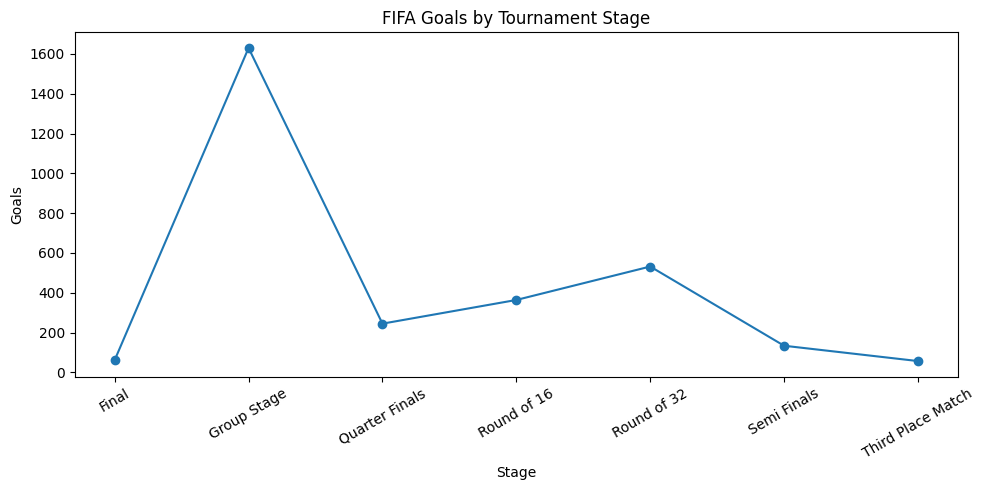

In [6]:
stage_goals=df.groupby("tournament_stage",as_index=False)["goals"].sum(); plt.figure(figsize=(10,5)); plt.plot(stage_goals["tournament_stage"],stage_goals["goals"],marker="o"); plt.title("FIFA Goals by Tournament Stage"); plt.xlabel("Stage"); plt.ylabel("Goals"); plt.xticks(rotation=30); plt.tight_layout(); plt.show()

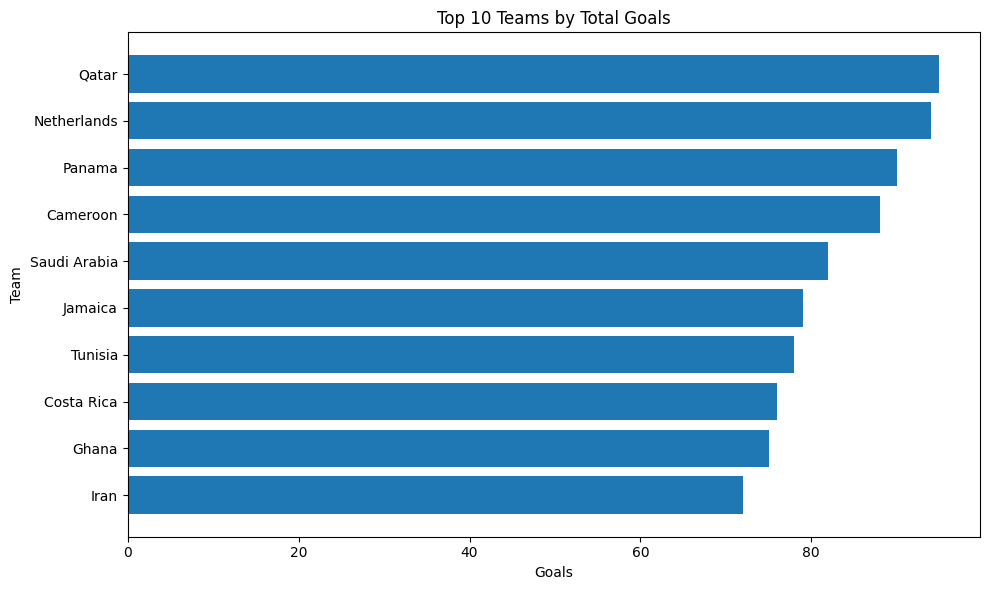

In [7]:
team_goals=df.groupby("team",as_index=False)["goals"].sum().sort_values("goals",ascending=False).head(10); plt.figure(figsize=(10,6)); plt.barh(team_goals["team"][::-1],team_goals["goals"][::-1]); plt.title("Top 10 Teams by Total Goals"); plt.xlabel("Goals"); plt.ylabel("Team"); plt.tight_layout(); plt.show()

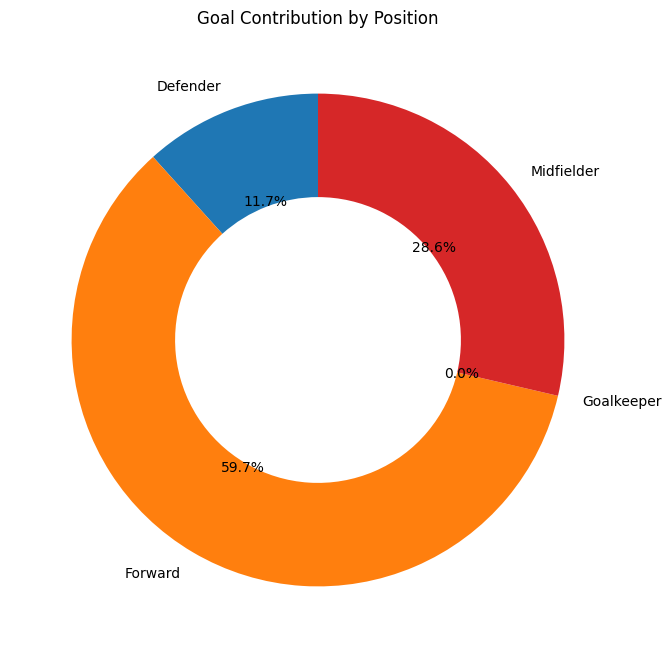

In [8]:
positions=df.groupby("position")["goals"].sum(); plt.figure(figsize=(8,8)); plt.pie(positions.values,labels=positions.index,autopct="%1.1f%%",startangle=90,wedgeprops={"width":.42}); plt.title("Goal Contribution by Position"); plt.show()

In [9]:
print("Date range:",df.match_date.min().date(),"to",df.match_date.max().date()); print("Number of match dates:",df.match_date.nunique())

Date range: 2026-06-11 to 2026-07-31
Number of match dates: 51


In [10]:
print("DAX examples:"); print("Total Goals = SUM(FIFA[goals])"); print("Total Matches = DISTINCTCOUNT(FIFA[match_id])"); print("Total Players = DISTINCTCOUNT(FIFA[player_id])"); print("Goal Involvement = SUM(FIFA[goals]) + SUM(FIFA[assists])")

DAX examples:
Total Goals = SUM(FIFA[goals])
Total Matches = DISTINCTCOUNT(FIFA[match_id])
Total Players = DISTINCTCOUNT(FIFA[player_id])
Goal Involvement = SUM(FIFA[goals]) + SUM(FIFA[assists])
